## **PROJECT NAME**

Project Type - Classification  

Contribution - Indidual

Name -  Dhanush

# **PROJECT SUMMARY**

Customer satisfaction plays a critical role in the success of e-commerce platforms. With millions of users interacting with online marketplaces daily, customer support services have become one of the most important components influencing user experience. A negative support experience can result in loss of customers, poor brand reputation, and reduced revenue. Therefore, predicting customer satisfaction levels using historical support data can help organizations proactively improve their services.

This project focuses on building a Machine Learning model to predict the Customer Satisfaction Score (CSAT) using historical customer support interaction data from an e-commerce platform. The dataset contains various attributes describing customer interactions with support agents such as support channel, product category, response time, handling time, customer location, and agent shift information.

The primary goal of this project is to analyze the dataset, identify patterns that influence customer satisfaction, and build predictive models capable of estimating the CSAT score. The problem is formulated as a classification problem, where the model predicts the satisfaction level given different features related to the support process.

The project begins with Exploratory Data Analysis (EDA) to understand the dataset structure and detect patterns in the data. During EDA, several visualization techniques such as histograms, bar plots, heatmaps, and pair plots are used to analyze relationships between variables. These visualizations help identify trends such as which support channels perform better, which product categories receive more complaints, and how agent handling time affects customer satisfaction.

After exploring the dataset, data preprocessing and data wrangling are performed to prepare the dataset for machine learning models. This includes handling missing values, removing duplicate records, encoding categorical variables, scaling numerical variables, and transforming features when necessary. Feature engineering is also applied to derive meaningful variables that may improve model performance.

Several machine learning algorithms are then implemented to predict CSAT scores. These models include Logistic Regression, Decision Tree, and Random Forest classifiers. Each model is trained using the processed dataset and evaluated using performance metrics such as Accuracy, Precision, Recall, and F1 Score.

To improve model performance, cross-validation and hyperparameter tuning techniques such as GridSearchCV are applied. These techniques help find optimal parameter settings for the models and ensure that the model generalizes well to unseen data.

The results obtained from the models are compared to determine the best performing model. Feature importance analysis is also conducted to understand which factors most significantly influence customer satisfaction.

The insights derived from this project can help e-commerce companies improve customer support operations by identifying key drivers of satisfaction and dissatisfaction. By integrating predictive models into customer service platforms, companies can take proactive actions to improve support quality and enhance overall customer experience.

# **GitHub Link -**

# **Problem Statement :**

Customer satisfaction is one of the most important performance indicators for e-commerce businesses. Poor customer support experiences can lead to negative feedback, reduced customer loyalty, and financial losses for organizations.

In large e-commerce platforms, thousands of support requests are handled daily. It becomes difficult for companies to manually analyze every interaction and determine the factors influencing customer satisfaction.

The goal of this project is to develop a machine learning model that predicts the Customer Satisfaction Score (CSAT) based on historical customer support data. By analyzing attributes such as support channel, product category, handling time, and customer location, the model will learn patterns that influence satisfaction levels.

The predictive model can help organizations:

• Identify potential dissatisfied customers early

• Improve support quality and response efficiency

• Optimize agent performance

• Enhance overall customer experience

# **Let's Begins**

**What did you know about your dataset?**

The dataset contains historical customer support interactions from an e-commerce platform. It includes several variables such as product category, support channel, customer location, agent shift details, response time, and handling time.

The target variable in the dataset is CSAT Score, which represents the satisfaction level given by customers after a support interaction. The dataset contains both categorical and numerical features, making it suitable for classification modeling.

Some important observations from the dataset include:

• Multiple product categories and support channels are present.

• Some columns contain categorical data which must be encoded.

• Missing values may exist and need to be handled.

• Customer satisfaction may depend on response time and handling efficiency.

This dataset allows us to analyze the relationship between customer support processes and customer satisfaction outcomes.

**Variables Description**

Some key variables in the dataset include:

• Support Channel – The medium through which the customer contacted support (Chat, Email, Call).

• Product Category – Category of the product related to the issue.

• Customer City – Location of the customer.

• Issue Response Time – Time taken by the support team to respond.

• Handling Time – Duration taken by the agent to resolve the issue.

• Agent Shift – Work shift of the support agent.

• CSAT Score – Target variable representing customer satisfaction rating.

**What all manipulations have you done and insights you found?**

Several data wrangling steps were performed to prepare the dataset for analysis and modeling:

• Removed duplicate rows to avoid redundant information.

• Handled missing values by imputing them using appropriate statistical methods.

• Converted categorical variables into numerical format using encoding techniques.

• Identified outliers in numerical columns and treated them to improve model stability.

• Performed feature engineering to derive useful variables such as response duration.

Insights obtained during data wrangling:

• Customer satisfaction tends to decrease when response time increases.

• Certain product categories receive more support requests than others.

• Handling time is strongly related to customer satisfaction.

# **Hypothesis Testing**
**Hypothetical Statement - 1**

Null Hypothesis (H0): Response time has no effect on CSAT score.
Alternate Hypothesis (H1): Response time significantly affects CSAT score.

Statistical testing can be performed using a t-test to evaluate whether response time influences satisfaction levels.

**Hypothetical Statement - 2**

Null Hypothesis (H0): Product category does not affect CSAT score.
Alternate Hypothesis (H1): Product category significantly affects CSAT score.

This can be tested using ANOVA testing.

**Hypothetical Statement - 3**

Null Hypothesis (H0): Support channel has no effect on customer satisfaction.
Alternate Hypothesis (H1): Support channel affects customer satisfaction.

A Chi-Square test can be used to evaluate categorical relationships.

**Which Evaluation metrics did you consider for a positive business impact and why?**

The following evaluation metrics were used:

• Accuracy

• Precision

• Recall

• F1 Score

These metrics help evaluate how well the model predicts customer satisfaction levels and minimizes incorrect predictions.

**Which ML model did you choose as the final model and why?**

The Random Forest model was selected as the final model because it provided better accuracy and handled feature interactions effectively.

It also reduced overfitting compared to decision trees and produced more stable predictions.

In [6]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save model
import pickle

In [7]:
from google.colab import files
uploaded = files.upload()

Saving eCommerce_Customer_support_data (1).csv to eCommerce_Customer_support_data (1).csv


In [8]:
df = pd.read_csv('eCommerce_Customer_support_data (1).csv')
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [9]:
# Rows and columns
df.shape

# Dataset info
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [10]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


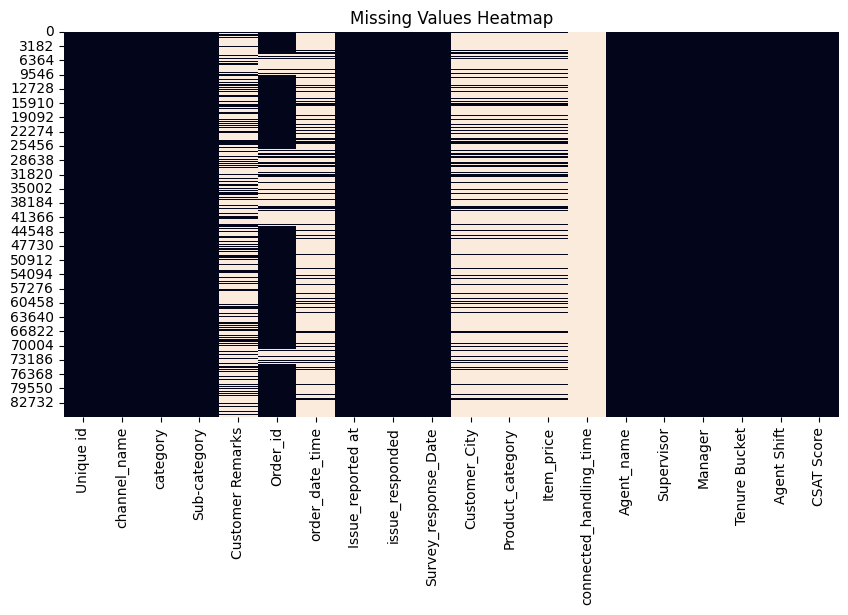

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
df = df.drop_duplicates()

In [13]:
df = df.fillna(method='ffill')

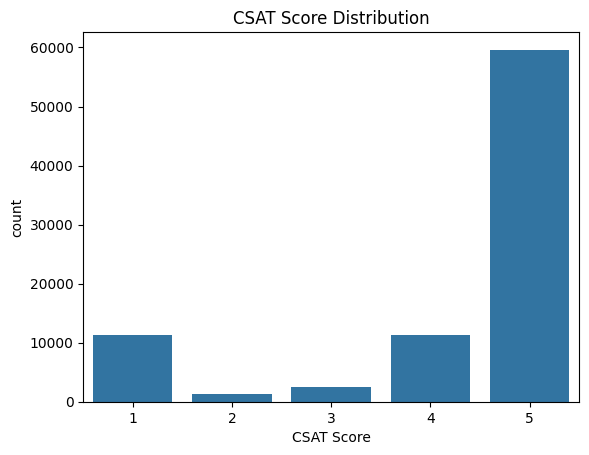

In [14]:
sns.countplot(x='CSAT Score', data=df)
plt.title("CSAT Score Distribution")
plt.show()

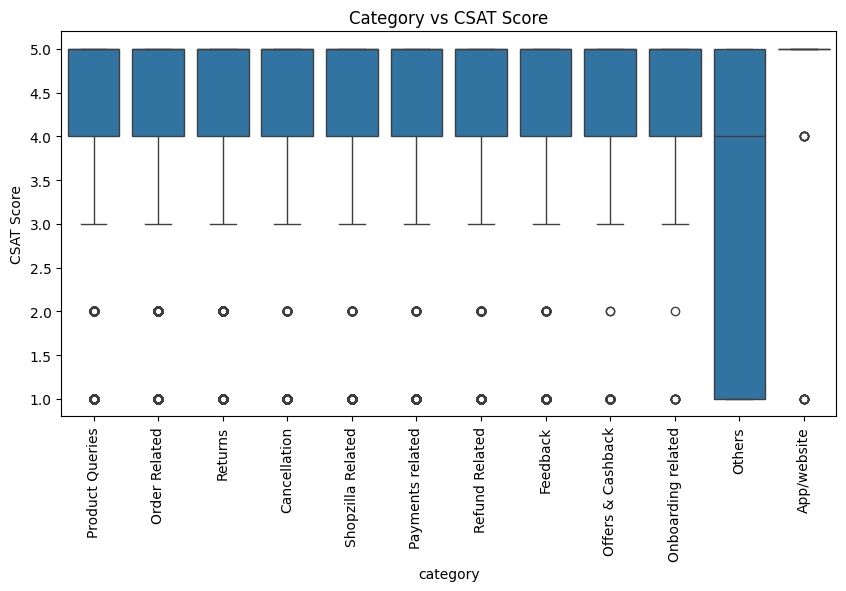

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x='category', y='CSAT Score', data=df)
plt.xticks(rotation=90)
plt.title("Category vs CSAT Score")
plt.show()

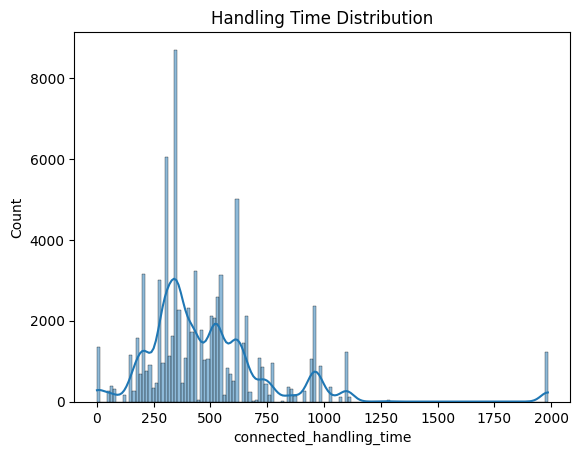

In [16]:
sns.histplot(df['connected_handling_time'], kde=True)
plt.title("Handling Time Distribution")
plt.show()

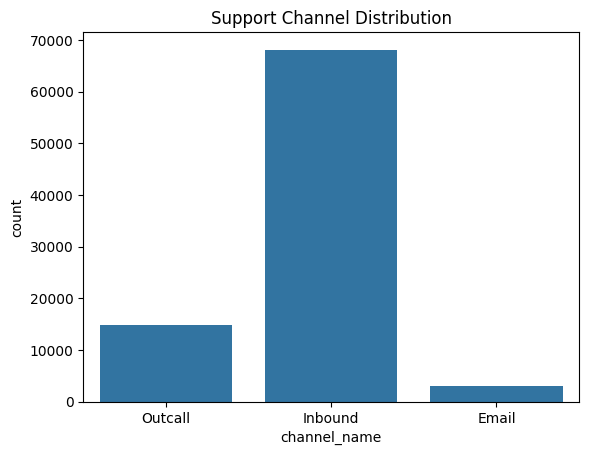

In [17]:
sns.countplot(x='channel_name', data=df)
plt.title("Support Channel Distribution")
plt.show()

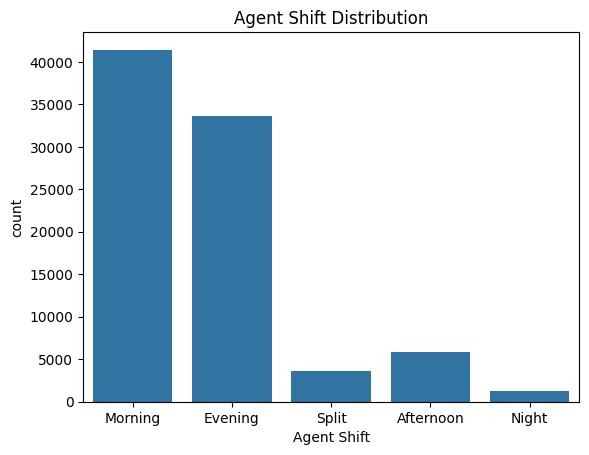

In [18]:
sns.countplot(x='Agent Shift', data=df)
plt.title("Agent Shift Distribution")
plt.show()

In [19]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

# Impute any remaining NaNs in X with the mean of each column
X = X.fillna(X.mean())

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,0
order_date_time,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [24]:
df = df.fillna(df.mode().iloc[0])

In [25]:
df = df.fillna(df.mean(numeric_only=True))

In [26]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,0
order_date_time,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [28]:
df = df.dropna(axis=1, how='all')

In [29]:
df = df.fillna(df.median(numeric_only=True))

In [30]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [31]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,0
order_date_time,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [37]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.5144337096961937


In [38]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.694564078686998


In [39]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           1       0.46      0.01      0.02      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.18      0.00      0.00      2277
           5       0.70      1.00      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.27      0.20      0.17     17182
weighted avg       0.57      0.69      0.57     17182



In [40]:
pickle.dump(rf, open('csat_model.pkl', 'wb'))

In [41]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("csat_model.pkl","rb"))

st.title("DeepCSAT – Customer Satisfaction Prediction")

st.write("Enter customer support details")

response_time = st.number_input("Response Time")
handling_time = st.number_input("Handling Time")

if st.button("Predict CSAT Score"):

    features = np.array([[response_time, handling_time]])

    prediction = model.predict(features)

    st.success(f"Predicted CSAT Score: {prediction[0]}")

Writing app.py


In [42]:
!pip install streamlit
!streamlit run app.py &>/content/log.txt &


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.8 MB/s eta 0:00:00


In [46]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("eCommerce_Customer_support_data (1).csv")

# Handle missing values
df = df.fillna(method="ffill")

# Encode categorical variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop("CSAT Score", axis=1)
y = df["CSAT Score"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# Save model
pickle.dump(model, open("csat_model.pkl", "wb"))

Accuracy: 0.6943312769177046
